# Section 1: Data filtering


In [9]:
from pathlib import Path

import numpy as np
import shnitsel as st
from ase.io import iread
from shnitsel.clean import sanity_check

N_REMOVED_TRAJECTORIES = 60
DATA_DIR = Path("../data/A01_ethene/dynamic_gitignore")

dt = st.io.read(DATA_DIR / "A01_ethene_0p50fs_dynamic.nc")
dt.dataset["atXYZ"].attrs["units"] = "angstrom"
source_index = dt.dataset.indexes["frame"]
discarded_trajectories = dt.dataset["trajectory"].values[:N_REMOVED_TRAJECTORIES]
dt = type(dt)(dt.dataset.where(~dt.dataset["atrajectory"].isin(discarded_trajectories), drop=True))
filtered_dt = sanity_check(dt, "truncate")

retained_positions = source_index.get_indexer(filtered_dt.dataset.indexes["frame"])
assert np.all(retained_positions >= 0) and len(set(retained_positions)) == len(retained_positions)
assert not np.isin(filtered_dt.dataset["atrajectory"], discarded_trajectories).any()

keep_positions = set(retained_positions)
filtered_xyz_frames = [atoms for i, atoms in enumerate(iread(DATA_DIR / "A01_ethene_dynamic_CASSCF_with_nacs.xyz", ":")) if i in keep_positions]
assert len(filtered_xyz_frames) == len(retained_positions)


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/shnitsel/units/conversion.py:235: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'frame'} to avoid an error in the future.
  tmp = data.assign(new_vars)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/shnitsel/clean/filter_energy.py:171: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'frame'} to avoid an error in the future.
  res["epot_hop_step"] = mdiff(e_pot_active).where(is_hop, 0)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/shnitsel/clean/filter_energy.py:183: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'frame'} to avoid

# Section 2: Finding sigma_gap for near-CI sampling distribution


Filtered configurations: 31002
REF_energy conversion: eV × 1.0 = eV (no conversion required)
Missing/malformed REF_energy: 0
Non-finite energies (S0, S1, S2): [0, 0, 0]
Configurations with any non-finite energy: 0
Negative ΔE01: 0
Negative ΔE12: 0
ΔE01 (eV): min=0.010323; p1=0.245854, p5=0.729582, p10=1.186117, p25=2.633517, p50=4.329186, p75=6.709619, p90=8.443145, p95=9.043880, p99=9.647194
ΔE12 (eV): min=0.128528; p1=0.258483, p5=0.562921, p10=0.929238, p25=1.799992, p50=3.012356, p75=4.169039, p90=4.942514, p95=5.331697, p99=6.126073


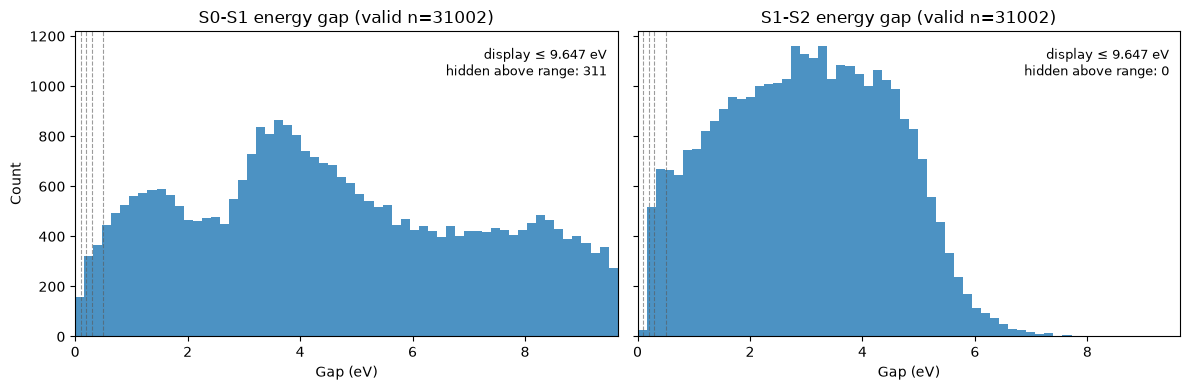

In [10]:
import matplotlib.pyplot as plt

energy_to_ev = 1.0  # REF_energy is already stored in eV.
n_configurations = len(filtered_xyz_frames)
energies = np.full((n_configurations, 3), np.nan)
malformed_ref_energy = []
for i, atoms in enumerate(filtered_xyz_frames):
    try:
        value = np.asarray(atoms.info["REF_energy"], dtype=float).reshape(-1)
    except (KeyError, TypeError, ValueError):
        value = np.array([])
    if value.size != 3:
        malformed_ref_energy.append(i)
    else:
        energies[i] = value
energies *= energy_to_ev

print(f"Filtered configurations: {n_configurations}")
print("REF_energy conversion: eV × 1.0 = eV (no conversion required)")
print(f"Missing/malformed REF_energy: {len(malformed_ref_energy)}")
finite_energy = np.isfinite(energies)
print("Non-finite energies (S0, S1, S2):", (~finite_energy).sum(axis=0).tolist())
print(f"Configurations with any non-finite energy: {(~finite_energy.all(axis=1)).sum()}")

gap_01, gap_12 = energies[:, 1] - energies[:, 0], energies[:, 2] - energies[:, 1]
def report_affected(label, gap):
    negative = np.isfinite(gap) & (gap < 0)
    print(f"Negative {label}: {negative.sum()}")
    for i in np.flatnonzero(negative)[:5]:
        print(f"  filtered_xyz_frames[{i}]: energies={energies[i].tolist()}, {label}={gap[i]:.6f} eV")
    return np.isfinite(gap) & (gap >= 0)

valid_01, valid_12 = report_affected("ΔE01", gap_01), report_affected("ΔE12", gap_12)
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for label, gap, valid in [("ΔE01", gap_01, valid_01), ("ΔE12", gap_12, valid_12)]:
    values = gap[valid]
    if not len(values):
        raise ValueError(f"No valid {label} values available")
    stats = np.percentile(values, percentiles)
    print(f"{label} (eV): min={values.min():.6f}; " + ", ".join(f"p{p}={v:.6f}" for p, v in zip(percentiles, stats)))

display_max = max(0.5, np.percentile(gap_01[valid_01], 99), np.percentile(gap_12[valid_12], 99))
bins = np.linspace(0, display_max, 61)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, label, gap, valid in zip(axes, ["S0-S1 energy gap", "S1-S2 energy gap"], [gap_01, gap_12], [valid_01, valid_12]):
    values = gap[valid]
    hidden = (values > display_max).sum()
    ax.hist(values[values <= display_max], bins=bins, color="C0", alpha=0.8)
    for reference in [0.1, 0.2, 0.3, 0.5]:
        ax.axvline(reference, color="0.35", lw=0.8, ls="--", alpha=0.6)
    ax.set(title=f"{label} (valid n={len(values)})", xlabel="Gap (eV)", xlim=(0, display_max))
    ax.text(0.98, 0.95, f"display ≤ {display_max:.3f} eV\nhidden above range: {hidden}", transform=ax.transAxes, ha="right", va="top", fontsize=9)
axes[0].set_ylabel("Count")
fig.tight_layout()
plt.show()


In [11]:
sigma_candidates = np.array([
    0.05, 0.075, 0.10, 0.125,
    0.15, 0.20, 0.25, 0.30
])
total_test_size = 2000

# Each gap-biased component will contain 25% of the final test set.
target_gap_sample_size = (
    total_test_size // 4 if total_test_size is not None else None
)

def effective_sample_size(gaps, sigma_gap):
    log_weights = -0.5 * (gaps / sigma_gap) ** 2
    log_weights -= log_weights.max()
    weights = np.exp(log_weights)
    probabilities = weights / weights.sum()
    return 1 / np.sum(probabilities ** 2)

def ess_status(ess):
    if target_gap_sample_size is None:
        return "target unavailable"
    if ess < target_gap_sample_size:
        return "too concentrated"
    if ess < 2 * target_gap_sample_size:
        return "usable but concentrated"
    return "comfortably diverse"

gap_pools = [("ΔE01", gap_01[valid_01]), ("ΔE12", gap_12[valid_12])]
for sigma_gap in sigma_candidates:
    print(f"sigma_gap = {sigma_gap:.3f} eV")
    for label, gaps in gap_pools:
        ess = effective_sample_size(gaps, sigma_gap)
        print(f"  {label}: N_eff={ess:.1f} ({ess / len(gaps):.2%} of n={len(gaps)}); {ess_status(ess)}")

print("\nChoose sigma_01 and sigma_12 separately. Smaller sigma values concentrate on very small gaps; larger values include broader gap ranges. Prefer the smallest sigma with N_eff at least twice the intended 25% component size. Treat 0.15 eV as a reference candidate, not an automatic selection.")


sigma_gap = 0.050 eV
  ΔE01: N_eff=65.6 (0.21% of n=31002); too concentrated
  ΔE12: N_eff=37.7 (0.12% of n=31002); too concentrated
sigma_gap = 0.075 eV
  ΔE01: N_eff=128.7 (0.42% of n=31002); too concentrated
  ΔE12: N_eff=137.3 (0.44% of n=31002); too concentrated
sigma_gap = 0.100 eV
  ΔE01: N_eff=204.2 (0.66% of n=31002); too concentrated
  ΔE12: N_eff=271.1 (0.87% of n=31002); too concentrated
sigma_gap = 0.125 eV
  ΔE01: N_eff=292.2 (0.94% of n=31002); too concentrated
  ΔE12: N_eff=419.6 (1.35% of n=31002); too concentrated
sigma_gap = 0.150 eV
  ΔE01: N_eff=387.8 (1.25% of n=31002); too concentrated
  ΔE12: N_eff=579.3 (1.87% of n=31002); usable but concentrated
sigma_gap = 0.200 eV
  ΔE01: N_eff=593.5 (1.91% of n=31002); usable but concentrated
  ΔE12: N_eff=919.0 (2.96% of n=31002); usable but concentrated
sigma_gap = 0.250 eV
  ΔE01: N_eff=819.5 (2.64% of n=31002); usable but concentrated
  ΔE12: N_eff=1270.1 (4.10% of n=31002); comfortably diverse
sigma_gap = 0.300 eV
  ΔE

## Section 3: Sampling


In [12]:
def near_ci_log_weights(gaps, sigma):
    if sigma <= 0:
        raise ValueError("sigma must be positive")
    return -0.5 * (np.asarray(gaps) / sigma) ** 2

def probabilities_and_ess(log_weights):
    shifted = log_weights - log_weights.max()
    probabilities = np.exp(shifted)
    probabilities /= probabilities.sum()
    return probabilities, 1 / np.sum(probabilities ** 2)

def weighted_sample_without_replacement(pool, gap_column, sigma, sample_size, rng):
    if not 0 <= sample_size <= len(pool):
        raise ValueError("invalid weighted sample size")
    if sample_size == 0:
        return pool.iloc[[]].copy()
    probabilities, _ = probabilities_and_ess(near_ci_log_weights(pool[gap_column].to_numpy(), sigma))
    selected_positions = rng.choice(len(pool), size=sample_size, replace=False, p=probabilities)
    return pool.iloc[selected_positions].copy()

def construct_test_set(filtered_df, gap_01_column, gap_12_column, sigma_01, sigma_12, test_size, random_seed):
    if test_size <= 0:
        raise ValueError("test_size must be positive")
    pool = filtered_df.copy().reset_index(drop=True)
    if "configuration_id" not in pool:
        pool["configuration_id"] = np.arange(len(pool))
    if not pool["configuration_id"].is_unique:
        raise ValueError("configuration_id must be unique")
    pool = pool.loc[np.isfinite(pool[gap_01_column]) & np.isfinite(pool[gap_12_column]) & (pool[gap_01_column] >= 0) & (pool[gap_12_column] >= 0)].copy()
    if test_size > len(pool):
        raise ValueError("test_size exceeds the valid candidate pool")
    n_01, n_12 = test_size // 4, test_size // 4
    n_uniform = test_size - n_01 - n_12
    rng = np.random.default_rng(random_seed)
    uniform = pool.iloc[rng.choice(len(pool), size=n_uniform, replace=False)].copy()
    uniform["sampling_component"], uniform["sampling_sigma_eV"] = "uniform", np.nan
    remaining = pool.drop(index=uniform.index)
    ess_01 = probabilities_and_ess(near_ci_log_weights(remaining[gap_01_column], sigma_01))[1]
    ess_12 = probabilities_and_ess(near_ci_log_weights(remaining[gap_12_column], sigma_12))[1]
    first, second = (("gap_01", gap_01_column, sigma_01, n_01), ("gap_12", gap_12_column, sigma_12, n_12)) if ess_01 <= ess_12 else (("gap_12", gap_12_column, sigma_12, n_12), ("gap_01", gap_01_column, sigma_01, n_01))
    selections = [uniform]
    for label, gap_column, sigma, quota in (first, second):
        chosen = weighted_sample_without_replacement(remaining, gap_column, sigma, quota, rng)
        chosen["sampling_component"], chosen["sampling_sigma_eV"] = label, sigma
        selections.append(chosen)
        remaining = remaining.drop(index=chosen.index)
    test_df = pd.concat(selections, ignore_index=True).sample(frac=1, random_state=random_seed).reset_index(drop=True)
    diagnostics = {"candidate_pool": len(pool), "quotas": {"uniform": n_uniform, "gap_01": n_01, "gap_12": n_12}, "initial_remaining_ess": {"gap_01": ess_01, "gap_12": ess_12}, "weighted_order": [first[0], second[0]]}
    return test_df, diagnostics


In [13]:
import pandas as pd

gap_01_column, gap_12_column = "gap_01_eV", "gap_12_eV"
valid_sampling_pool = valid_01 & valid_12
filtered_df = pd.DataFrame({"configuration_id": np.arange(n_configurations)[valid_sampling_pool], "filtered_xyz_index": np.flatnonzero(valid_sampling_pool), gap_01_column: gap_01[valid_sampling_pool], gap_12_column: gap_12[valid_sampling_pool]})
test_set_size = 2000
random_seed = 42
sigma_01 = 0.25  # eV; editable selection from Section 2 candidates
sigma_12 = 0.20  # eV; editable selection from Section 2 candidates

test_df, sampling_diagnostics = construct_test_set(filtered_df, gap_01_column, gap_12_column, sigma_01, sigma_12, test_set_size, random_seed)
n_01, n_12 = test_set_size // 4, test_set_size // 4
n_uniform = test_set_size - n_01 - n_12
component_counts = test_df["sampling_component"].value_counts()
print(sampling_diagnostics)
print(component_counts.to_dict())
print(f"Unique configuration IDs: {test_df['configuration_id'].nunique()}")
print(f"Final test-set size: {len(test_df)}")
print(f"No duplicate configurations: {test_df['configuration_id'].is_unique}")
assert len(test_df) == test_set_size
assert test_df["configuration_id"].nunique() == test_set_size
assert component_counts.get("uniform", 0) == n_uniform
assert component_counts.get("gap_01", 0) == n_01
assert component_counts.get("gap_12", 0) == n_12


{'candidate_pool': 31002, 'quotas': {'uniform': 1000, 'gap_01': 500, 'gap_12': 500}, 'initial_remaining_ess': {'gap_01': np.float64(791.8615146680561), 'gap_12': np.float64(890.9906009004567)}, 'weighted_order': ['gap_01', 'gap_12']}
{'uniform': 1000, 'gap_12': 500, 'gap_01': 500}
Unique configuration IDs: 2000
Final test-set size: 2000
No duplicate configurations: True


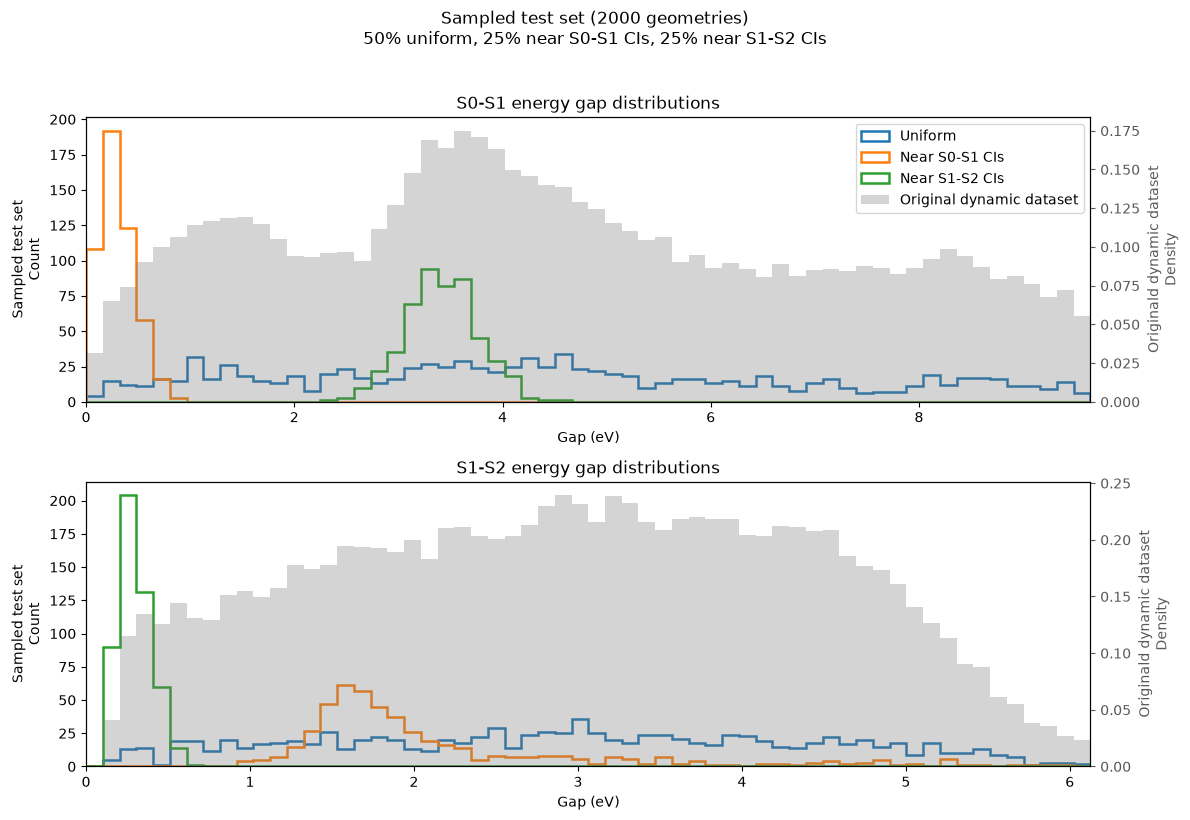

In [14]:
component_colors = {"uniform": "C0", "gap_01": "C1", "gap_12": "C2"}
component_labels = {"uniform": "Uniform", "gap_01": "Near S0-S1 CIs", "gap_12": "Near S1-S2 CIs"}
plot_limits = {column: max(0.5, np.percentile(filtered_df[column], 99)) for column in [gap_01_column, gap_12_column]}
plot_bins = {column: np.linspace(0, limit, 61) for column, limit in plot_limits.items()}

fig, axes = plt.subplots(2, figsize=(12, 8))
density_axes = []
for ax, column, title in [(axes[0], gap_01_column, "S0-S1 energy gap distributions"), (axes[1], gap_12_column, "S1-S2 energy gap distributions")]:
    density_ax = ax.twinx()
    density_axes.append(density_ax)
    original = filtered_df[column]
    density_ax.hist(original[original <= plot_limits[column]], bins=plot_bins[column], density=True, lw=1.8, alpha=0.3, color="0.45", label="Original dynamic dataset")
    for component, color in component_colors.items():
        values = test_df.loc[test_df.sampling_component == component, column]
        ax.hist(values[values <= plot_limits[column]], bins=plot_bins[column], density=False, histtype="step", lw=1.8, color=color, label=component_labels[component])
    ax.set(title=title, xlabel="Gap (eV)", ylabel="Sampled test set\nCount", xlim=(0, plot_limits[column]))
    density_ax.set_ylabel("Originald dynamic dataset\nDensity", color="0.35")
    density_ax.tick_params(axis="y", colors="0.35")

handles, labels = axes[0].get_legend_handles_labels()
density_handles, density_labels = density_axes[0].get_legend_handles_labels()
axes[0].legend(handles + density_handles, labels + density_labels)

fig.suptitle(f"Sampled test set ({len(test_df)} geometries)\n50% uniform, 25% near S0-S1 CIs, 25% near S1-S2 CIs", y=1.02)
plt.tight_layout()
plt.show()


In [15]:
print(
    test_df.groupby("sampling_component")[
    ["gap_01_eV", "gap_12_eV"]
].quantile([0.1, 0.5, 0.9])
)

threshold = 0.5

both_small = (
    (test_df["gap_01_eV"] < threshold)
    & (test_df["gap_12_eV"] < threshold)
)

print("Both gaps < 0.5 eV:", both_small.sum())

                        gap_01_eV  gap_12_eV
sampling_component                          
gap_01             0.1   0.107258   1.413084
                   0.5   0.281169   1.795397
                   0.9   0.532485   3.531510
gap_12             0.1   2.975762   0.186700
                   0.5   3.407007   0.288008
                   0.9   3.874667   0.437391
uniform            0.1   1.101508   0.910195
                   0.5   4.276364   2.987687
                   0.9   8.465156   5.013320
Both gaps < 0.5 eV: 0


In [16]:
from ase.io import write

OUTPUT_XYZ = Path("../data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_custom_test_set.xyz")
OUTPUT_PATHS = {"all": OUTPUT_XYZ, **{component: OUTPUT_XYZ.with_name(f"{OUTPUT_XYZ.stem}_{component}{OUTPUT_XYZ.suffix}") for component in ["uniform", "gap_01", "gap_12"]}}

def frames_for_export(rows):
    frames = [filtered_xyz_frames[int(i)].copy() for i in rows["filtered_xyz_index"]]
    assert all({"REF_energy", "REF_forces"} <= frame.info.keys() for frame in frames)
    for frame, (_, row) in zip(frames, rows.iterrows()):
        frame.info.update(configuration_id=int(row.configuration_id), sampling_component=row.sampling_component, sampling_sigma_eV=row.sampling_sigma_eV)
    return frames

for component, path in OUTPUT_PATHS.items():
    rows = test_df if component == "all" else test_df.loc[test_df.sampling_component == component]
    write(path, frames_for_export(rows), format="extxyz")
    print(f"Wrote {len(rows)} frames with REF_energy and REF_forces to {path.resolve()}")


Wrote 2000 frames with REF_energy and REF_forces to /home/lim_yt/X-MACE-sampling/data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_custom_test_set.xyz
Wrote 1000 frames with REF_energy and REF_forces to /home/lim_yt/X-MACE-sampling/data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_custom_test_set_uniform.xyz
Wrote 500 frames with REF_energy and REF_forces to /home/lim_yt/X-MACE-sampling/data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_custom_test_set_gap_01.xyz
Wrote 500 frames with REF_energy and REF_forces to /home/lim_yt/X-MACE-sampling/data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_custom_test_set_gap_12.xyz


## Selected-frame geometry coverage

Plot the selected test-set frames by C–C bond length and HCCH dihedral.

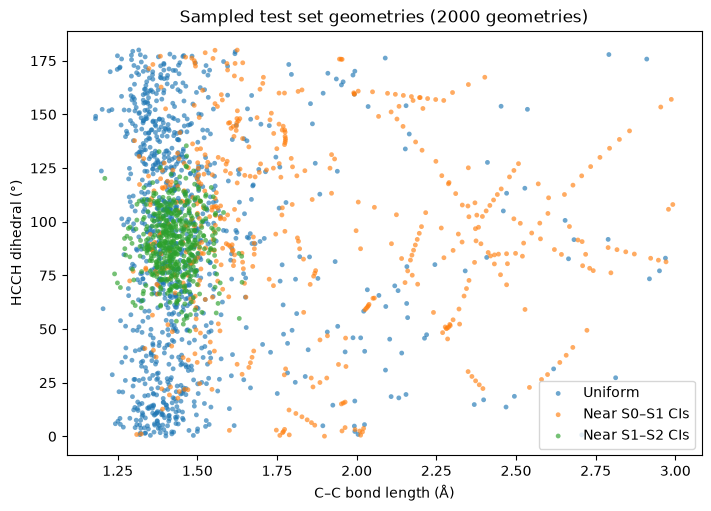

In [17]:
import matplotlib.pyplot as plt
import numpy as np

required_columns = {"filtered_xyz_index", "sampling_component"}
missing_columns = required_columns - set(test_df.columns)
if missing_columns:
    raise RuntimeError(
        "Run the sampling cell first; test_df is missing " + ", ".join(sorted(missing_columns))
    )

selected_indices = test_df["filtered_xyz_index"].to_numpy(dtype=int)
if np.any(selected_indices < 0) or np.any(selected_indices >= len(filtered_xyz_frames)):
    raise IndexError("test_df contains an invalid filtered_xyz_index")

selected_frames = [filtered_xyz_frames[index] for index in selected_indices]
cc_bond_lengths = np.asarray([frame.get_distance(0, 1) for frame in selected_frames])
hcch_dihedrals = np.asarray([
    frame.get_dihedral(2, 0, 1, 3) for frame in selected_frames
])
# HCCH torsions are equivalent when reflected about 180°; fold them to 0–180°.
hcch_dihedrals = np.minimum(hcch_dihedrals, 360.0 - hcch_dihedrals)

component_colors = {"uniform": "C0", "gap_01": "C1", "gap_12": "C2"}
component_labels = {
    "uniform": "Uniform",
    "gap_01": "Near S0–S1 CIs",
    "gap_12": "Near S1–S2 CIs",
}

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for component, color in component_colors.items():
    mask = test_df["sampling_component"].to_numpy() == component
    ax.scatter(
        cc_bond_lengths[mask], hcch_dihedrals[mask],
        s=12, alpha=0.65, color=color, edgecolors="none",
        label=component_labels[component],
    )

ax.set(
    title=f"Sampled test set geometries ({len(selected_frames)} geometries)",
    xlabel="C–C bond length (Å)",
    ylabel="HCCH dihedral (°)",
)
ax.legend()
plt.show()
